## 5.2	Case Study: Global Rainfall Data for Model Calibration in Rugunga

In [1]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [3]:
# Gitega Station Data
#gitega_df = pd.read_csv('Rainfall Station Data\Gitega_StationData.csv', parse_dates=['Date'])
gitega_df = pd.read_csv("Gitega station Data.csv")
gitega_df['Date'] = pd.to_datetime(gitega_df[['Year', 'Month', 'Day']])
#CHIRPS
gitega_chirps_df = pd.read_csv('Rainfall Station Data\gitega_chirps.csv', parse_dates=['Unnamed: 0'])
gitega_chirps_df.rename(columns = {'Unnamed: 0': 'Date'}, inplace = True)

#Rainfall-Runoff Model
model_df = pd.read_csv("Model Data\Time series for model results_Rugunga.csv", parse_dates = ['Date'])

gauge = gitega_df.set_index('Date')['PRECIP(mm)']
chirps = gitega_chirps_df.set_index('Date')['Gitega']
model = model_df.set_index('Date')
merged_df = pd.concat([gauge, chirps], axis=1, join='inner').dropna()
merged_df = merged_df.rename(columns={'PRECIP(mm)': 'Gauge', 'Gitega': 'CHIRPS'})
                               
merged_df_discharge = pd.merge(merged_df, model, on = 'Date').drop(columns= ['Inflow from R1(m3/s)','Inflow from S5 M3/S'])
merged_df_discharge = merged_df_discharge.rename(columns={'Date': 'Time', 'Discharge (M3/S)': 'Total Inflow (M3/S)', 'Observed Discharge (M3/S)': 'Obs Flow (M3/S)'})
#mask = (merged_df.index >= '2023-10-02') & (merged_df.index <= '2024-09-02')
#merged_df = merged_df[mask]

C:\Users\ezuet\AppData\Local\Temp\ipykernel_21080\2077348870.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  model_df = pd.read_csv("Model Data\Time series for model results_Rugunga.csv", parse_dates = ['Date'])


KeyError: 'Unnamed: 0'

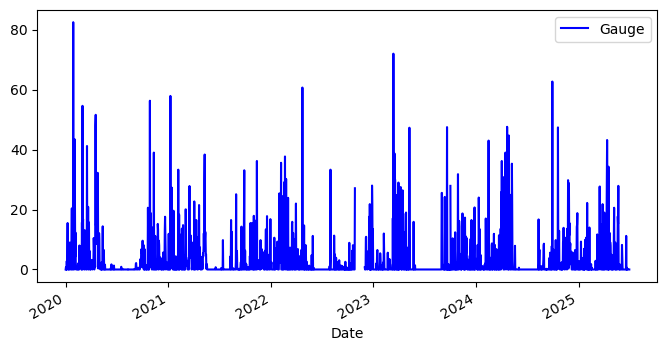

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

# Plot directly
gitega_df.plot(x = 'Date', y='PRECIP(mm)', ax=ax, label='Gauge', color='blue')
gitega_chirps_df.plot(y = 'Gitega', x='Unnamed: 0', ax=ax, color = 'orange', label = 'CHIRPS')

ax.set_xlim(['2021-01-01', '2023-12-31'])

# Calculate Pearson correlation over the plotted period
gauge = gitega_df.set_index('Date')['PRECIP(mm)']
chirps = gitega_chirps_df.set_index('Unnamed: 0')['Gitega']
merged = pd.concat([gauge, chirps], axis=1, join='inner').dropna()
merged.columns = ['Gauge', 'CHIRPS']
mask = (merged.index >= '2021-01-01') & (merged.index <= '2023-12-31')
r = merged[mask]['Gauge'].corr(merged[mask]['CHIRPS'])

ax.text(0.02, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.gcf().autofmt_xdate()
plt.legend()
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')

plt.tight_layout()
plt.show()

C:\Users\ezuet\AppData\Local\Temp\ipykernel_21080\1694898475.py:255: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_diff.legend(frameon=False, loc="lower left", handlelength=1.4)


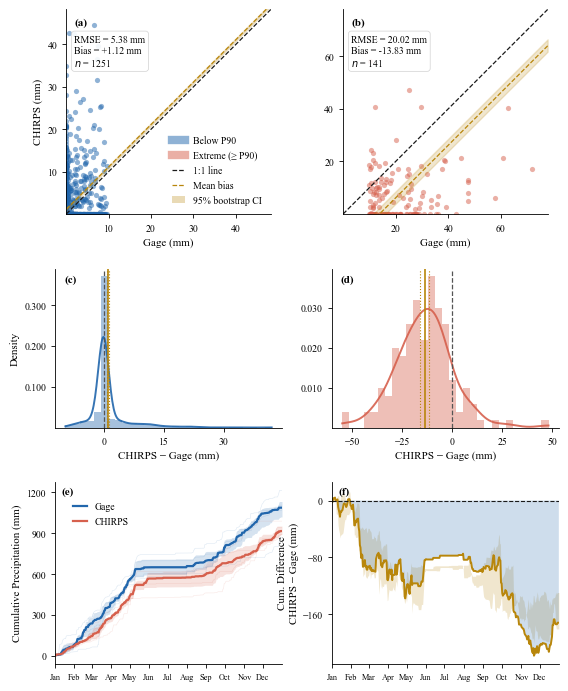

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import numpy as np
from scipy import stats
from scipy.stats import gaussian_kde

# ── Publication style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         8,
    "axes.labelsize":    8,
    "axes.titlesize":    9,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
    "legend.fontsize":   7,
    "axes.linewidth":    0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "xtick.major.size":  3,
    "ytick.major.size":  3,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

# ── Palette ───────────────────────────────────────────────────────────────────
C_BELOW  = "#2166ac"
C_ABOVE  = "#d6604d"
C_REF    = "#1a1a1a"
C_BOOT   = "#b8860b"
C_ZERO   = "#555555"
ALPHA_SC = 0.50
ALPHA_CI = 0.20

# ── Data ─────────────────────────────────────────────────────────────────────
gauge  = merged_df['Gauge']
chirps = merged_df['CHIRPS']

q90_thresh = gauge.quantile(0.9)
mask_all   = ~(np.isnan(gauge) | np.isnan(chirps))
mask_below = mask_all & (gauge < q90_thresh)
mask_above = mask_all & (gauge >= q90_thresh)

# ── Stats helpers ─────────────────────────────────────────────────────────────
def bootstrap_bias_ci(diff, n_boot=2000, ci=95):
    rng = np.random.default_rng(42)
    boot_means = np.array([
        rng.choice(diff, size=len(diff), replace=True).mean()
        for _ in range(n_boot)
    ])
    lo = np.percentile(boot_means, (100 - ci) / 2)
    hi = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lo, hi, boot_means

def compute_stats(g, c, n_boot=2000):
    diff = c - g
    bias = np.mean(diff)
    rmse = np.sqrt(np.mean(diff**2))
    lo, hi, boot_means = bootstrap_bias_ci(diff, n_boot=n_boot)
    slope, intercept, r, p, _ = stats.linregress(g, c)
    return dict(bias=bias, ci_lo=lo, ci_hi=hi,
                rmse=rmse, r2=r**2, slope=slope, intercept=intercept,
                n=len(diff), diff=diff, boot_means=boot_means)

s_below = compute_stats(gauge[mask_below].values, chirps[mask_below].values)
s_above = compute_stats(gauge[mask_above].values, chirps[mask_above].values)

# ── Cumulative sum data prep ──────────────────────────────────────────────────
_df = merged_df.copy()
_df['doy']  = _df.index.day_of_year
_df['year'] = _df.index.year
years    = sorted(_df['year'].unique())
all_doys = np.arange(1, 367)

gauge_cum  = np.full((366, len(years)), np.nan)
chirps_cum = np.full((366, len(years)), np.nan)

for yi, yr in enumerate(years):
    yrdf = _df[_df['year'] == yr]
    g = yrdf.set_index('doy')['Gauge'].reindex(all_doys)
    c = yrdf.set_index('doy')['CHIRPS'].reindex(all_doys)
    gauge_cum[:, yi]  = np.nancumsum(g)
    chirps_cum[:, yi] = np.nancumsum(c)

g_med  = np.nanmedian(gauge_cum,        axis=1)
g_p25  = np.nanpercentile(gauge_cum,  25, axis=1)
g_p75  = np.nanpercentile(gauge_cum,  75, axis=1)
c_med  = np.nanmedian(chirps_cum,       axis=1)
c_p25  = np.nanpercentile(chirps_cum, 25, axis=1)
c_p75  = np.nanpercentile(chirps_cum, 75, axis=1)
diff_med = c_med - g_med

month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_names  = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

# ── Layout: 3 rows × 2 cols, bottom row spans both columns ───────────────────
fig = plt.figure(figsize=(6.5, 8.5))
gs  = fig.add_gridspec(
    3, 2,
    height_ratios=[1.8, 1.4, 1.6],
    hspace=0.3,
    wspace=0.22,
)

ax_sc   = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]  # row 0: scatter
ax_hi   = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]  # row 1: histograms
ax_cum  = fig.add_subplot(gs[2, 0])                                # row 2: cumsum
ax_diff = fig.add_subplot(gs[2, 1])                                # row 2: cum difference

panel_cfg = [
    dict(mask=mask_below, s=s_below, color=C_BELOW,
         panel_sc="(a)", panel_hi="(c)"),
    dict(mask=mask_above, s=s_above, color=C_ABOVE,
         panel_sc="(b)", panel_hi="(d)"),
]
col_titles = [
    f"Below 90th Percentile  (< {q90_thresh:.1f} mm)",
    f"Extreme Events  (≥ {q90_thresh:.1f} mm)",
]

# ── Row 0: Scatter panels ─────────────────────────────────────────────────────
for col, cfg in enumerate(panel_cfg):
    ax = ax_sc[col]
    g  = gauge[cfg['mask']].values
    c  = chirps[cfg['mask']].values
    st = cfg['s']

    ax.scatter(g, c, alpha=ALPHA_SC, s=14, color=cfg['color'], linewidths=0)

    lim   = [0, max(g.max(), c.max()) * 1.08]
    x_fit = np.linspace(*lim, 200)

    ax.plot(lim, lim, color=C_REF, lw=0.9, ls="--")
    ax.fill_between(lim,
                    [lim[0]+st['ci_lo'], lim[1]+st['ci_lo']],
                    [lim[0]+st['ci_hi'], lim[1]+st['ci_hi']],
                    color=C_BOOT, alpha=ALPHA_CI)
    ax.plot(lim, [lim[0]+st['bias'], lim[1]+st['bias']],
            color=C_BOOT, lw=0.9, ls="--")

    textstr = "\n".join([
        f"RMSE = {st['rmse']:.2f} mm",
        f"Bias = {st['bias']:+.2f} mm",
        f"$n$ = {st['n']}",
    ])
    ax.text(0.04, 0.88, textstr, transform=ax.transAxes,
            va="top", ha="left", fontsize=7,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#cccccc", linewidth=0.5, alpha=0.9))

    ax.set_xlim(lim);  ax.set_ylim(lim)
    ax.set_aspect("equal")
    ax.set_xlabel("Gage (mm)", labelpad=3)
    ax.set_ylabel("CHIRPS (mm)" if col == 0 else "", labelpad=3)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5, prune="both"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5, prune="both"))
    ax.text(0.04, 0.96, cfg['panel_sc'], transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top")

# shared scatter legend on left panel
handles_sc = [
    Line2D([0],[0], color=C_BELOW, lw=6, alpha=0.5, label="Below P90"),
    Line2D([0],[0], color=C_ABOVE, lw=6, alpha=0.5, label="Extreme (≥ P90)"),
    Line2D([0],[0], color=C_REF,   lw=0.9, ls="--",  label="1:1 line"),
    Line2D([0],[0], color=C_BOOT,  lw=0.9, ls="--",  label="Mean bias"),
    plt.Rectangle((0,0),1,1, fc=C_BOOT, alpha=ALPHA_CI+0.1,
                  ec="none", label="95% bootstrap CI"),
]
ax_sc[0].legend(handles=handles_sc, frameon=False,
                loc="lower right", handlelength=1.4)

# ── Row 1: Histogram panels ───────────────────────────────────────────────────
for col, cfg in enumerate(panel_cfg):
    ax = ax_hi[col]
    st = cfg['s']

    diff  = st['diff']
    d_min, d_max = diff.min(), diff.max()
    bins  = np.linspace(d_min, d_max, 30)

    ax.hist(diff, bins=bins, density=True, color=cfg['color'],
            alpha=0.40, linewidth=0)

    x_kde = np.linspace(d_min, d_max, 300)
    kde   = gaussian_kde(diff, bw_method="scott")
    ax.plot(x_kde, kde(x_kde), color=cfg['color'], lw=1.4, alpha=0.90)

    ax.axvline(0,            color=C_ZERO, lw=0.9, ls="--")
    ax.axvline(st['bias'],   color=C_BOOT, lw=1.2, ls="-")
    ax.axvline(st['ci_lo'],  color=C_BOOT, lw=0.8, ls=":")
    ax.axvline(st['ci_hi'],  color=C_BOOT, lw=0.8, ls=":")

    ax.set_xlabel("CHIRPS − Gage (mm)", labelpad=3)
    ax.set_ylabel("Density" if col == 0 else "", labelpad=3)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(4, prune="both"))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5, prune="both"))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
    ax.text(0.04, 0.96, cfg['panel_hi'], transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="top")

# ── Row 2, left: Annual cumulative totals ─────────────────────────────────────
for yi in range(len(years)):
    ax_cum.plot(all_doys, gauge_cum[:, yi],  color=C_BELOW, lw=0.4, alpha=0.15)
    ax_cum.plot(all_doys, chirps_cum[:, yi], color=C_ABOVE, lw=0.4, alpha=0.15)

ax_cum.fill_between(all_doys, g_p25, g_p75, color=C_BELOW, alpha=0.18, linewidth=0)
ax_cum.fill_between(all_doys, c_p25, c_p75, color=C_ABOVE, alpha=0.18, linewidth=0)
ax_cum.plot(all_doys, g_med, color=C_BELOW, lw=1.6)
ax_cum.plot(all_doys, c_med, color=C_ABOVE, lw=1.6)

ax_cum.set_xticks(month_starts)
ax_cum.set_xticklabels(month_names, fontsize=6)
ax_cum.set_xlim(1, 366)
ax_cum.set_ylabel("Cumulative Precipitation (mm)", labelpad=3)
ax_cum.yaxis.set_major_locator(ticker.MaxNLocator(5, prune="both"))
ax_cum.text(0.03, 0.97, "(e)", transform=ax_cum.transAxes,
            fontsize=8, fontweight="bold", va="top")

handles_cum = [
    Line2D([0],[0], color=C_BELOW, lw=1.6, label="Gage"),
    Line2D([0],[0], color=C_ABOVE, lw=1.6, label="CHIRPS"),
]
ax_cum.legend(handles=handles_cum, frameon=False,
              loc="upper left",bbox_to_anchor=(0.04, 0.94), handlelength=1.4)

# ── Row 2, right: Cumulative difference ──────────────────────────────────────
ax_diff.fill_between(all_doys,
                     c_p25 - g_p25, c_p75 - g_p75,
                     color=C_BOOT, alpha=0.20, linewidth=0)
ax_diff.plot(all_doys, diff_med, color=C_BOOT, lw=1.4)
ax_diff.axhline(0, color=C_REF, lw=0.8, ls="--")

ax_diff.fill_between(all_doys, 0, diff_med,
                     where=diff_med >= 0,
                     color=C_ABOVE, alpha=0.22, linewidth=0)
ax_diff.fill_between(all_doys, 0, diff_med,
                     where=diff_med < 0,
                     color=C_BELOW, alpha=0.22, linewidth=0)

ax_diff.set_xticks(month_starts)
ax_diff.set_xticklabels(month_names, fontsize=6)
ax_diff.set_xlim(1, 366)
ax_diff.set_ylabel("Cum. Difference\nCHIRPS − Gage (mm)", labelpad=3)
ax_diff.yaxis.set_major_locator(ticker.MaxNLocator(4, prune="both"))

ax_diff.legend(frameon=False, loc="lower left", handlelength=1.4)
ax_diff.text(0.03, 0.97, "(f)", transform=ax_diff.transAxes,
             fontsize=8, fontweight="bold", va="top")

fig.savefig("gauge_vs_chirps_full.pdf", dpi=300, bbox_inches="tight")
fig.savefig("gauge_vs_chirps_full.png", dpi=300, bbox_inches="tight")
plt.show()

## Rainfall-Runoff Model

In [5]:
merged_df_discharge

,Gauge,CHIRPS,Time,Total Inflow (M3/S),Obs Flow (M3/S)
Date,,,,,
2023-10-02,27.9,0.000000,0:00,2.0,1.6
2023-10-03,0.0,0.000000,0:00,1.9,1.5
2023-10-04,0.0,0.000000,0:00,1.8,1.5
2023-10-05,0.0,0.000000,0:00,1.8,1.5
2023-10-06,0.0,0.000000,0:00,1.7,1.4
...,...,...,...,...,...
2024-03-26,0.0,9.402115,0:00,2.0,1.5
2024-03-27,0.5,0.000000,0:00,1.7,1.5
2024-03-28,5.8,0.000000,0:00,1.6,1.6


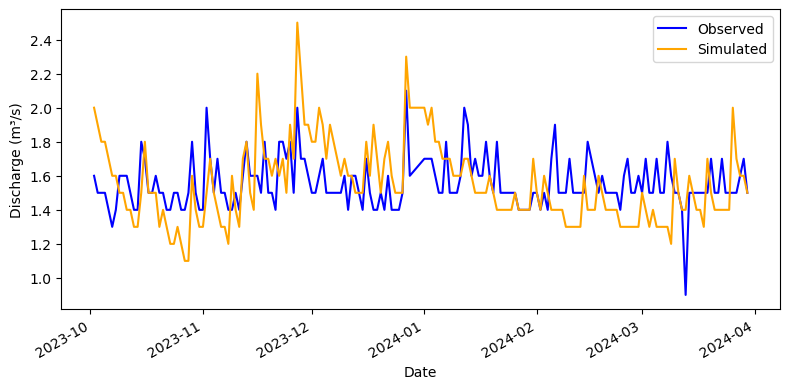

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

# Plot directly
merged_df_discharge.plot(y='Obs Flow (M3/S)', ax=ax, label='Observed', color='blue')
merged_df_discharge.plot(y='Total Inflow (M3/S)', ax=ax, label='Simulated', color='orange')
merged_df_discharge.plot(y='Total Inflow (M3/S)', ax=ax, label='Simulated', color='orange')
plt.gcf().autofmt_xdate()
plt.legend()
plt.xlabel('Date')
plt.ylabel('Discharge (m³/s)')

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

Correlation of rainfall with streamflow

In [12]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from scipy.stats import rankdata

def cross_correlogram(precip, streamflow, dt=1, time_units='hours', max_lag=None):
    """
    Compute and plot normalized cross-correlogram between precipitation and streamflow.
    
    Parameters
    ----------
    precip : array-like
        Precipitation time series
    streamflow : array-like
        Streamflow time series
    dt : float
        Timestep size (default 1)
    time_units : str
        Label for x-axis (default 'hours')
    max_lag : int, optional
        Max lag to display (in timesteps). Defaults to len/4.
    """
    p = rankdata(precip).astype(float)
    q = rankdata(streamflow).astype(float)

    p = (p - p.mean()) / p.std()
    q = (q - q.mean()) / q.std()
        
    # Normalize both series to zero mean, unit variance
    p = (p - p.mean()) / p.std()
    q = (q - q.mean()) / q.std()
    
    # Full cross-correlation
    corr = signal.correlate(q, p, mode='full')
    corr /= len(p)  # Normalize to get correlation coefficient [-1, 1]
    
    # Lag array in actual time units
    lags = signal.correlation_lags(len(p), len(q), mode='full') * dt
    
    # Trim to max_lag if specified
    if max_lag is not None:
        mask = np.abs(lags) <= max_lag
        lags, corr = lags[mask], corr[mask]
    
    # Find optimal lag
    peak_idx = np.argmax(corr)
    peak_lag = lags[peak_idx]
    peak_r = corr[peak_idx]
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(lags, corr, color='steelblue', lw=1.5)
    ax.axvline(0, color='gray', linestyle='--', lw=1, label='Zero lag')
    ax.axvline(peak_lag, color='firebrick', linestyle='--', lw=1.5,
               label=f'Peak lag = {peak_lag:.1f} {time_units} (r = {peak_r:.3f})')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xlabel(f'Lag ({time_units})')
    ax.set_ylabel('Correlation coefficient')
    ax.set_title('Precipitation–Streamflow Cross-Correlogram')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    return lags, corr, peak_lag, peak_r

In [15]:
mask = (merged_df_discharge.index >= '2023-10-15') & (merged_df_discharge.index <= '2024-09-02')
merged_df_discharge = merged_df_discharge[mask]

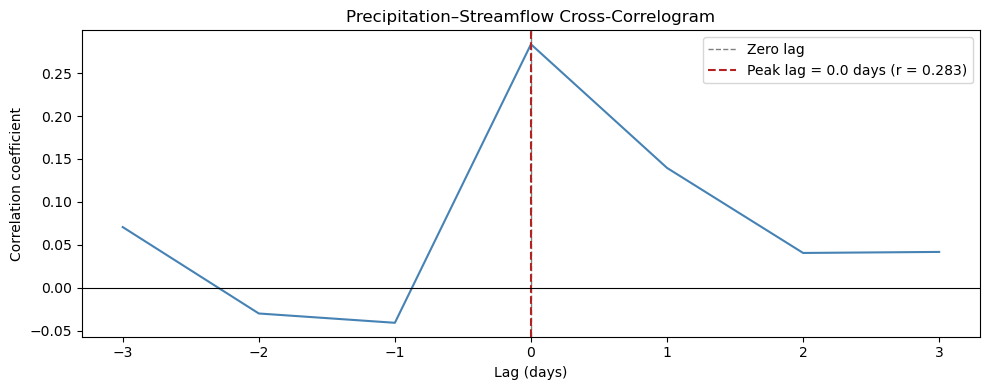

(array([-3, -2, -1,  0,  1,  2,  3]),
 array([ 0.070777  , -0.02977034, -0.04060091,  0.28349463,  0.13962086,
         0.04066327,  0.04186389]),
 np.int64(0),
 np.float64(0.2834946255240965))

In [16]:
cross_correlogram(merged_df_discharge['CHIRPS'], merged_df_discharge['Obs Flow (M3/S)'], dt=1, time_units='days', max_lag=3)

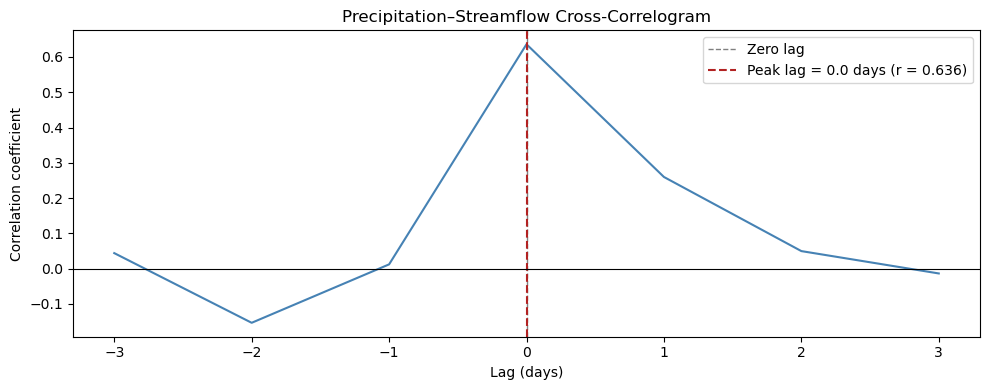

(array([-3, -2, -1,  0,  1,  2,  3]),
 array([ 0.04414805, -0.15328559,  0.01226884,  0.63598471,  0.25990708,
         0.04988502, -0.01346598]),
 np.int64(0),
 np.float64(0.6359847148280319))

In [17]:
cross_correlogram(merged_df_discharge['Gauge'], merged_df_discharge['Obs Flow (M3/S)'], dt=1, time_units='days', max_lag=3)

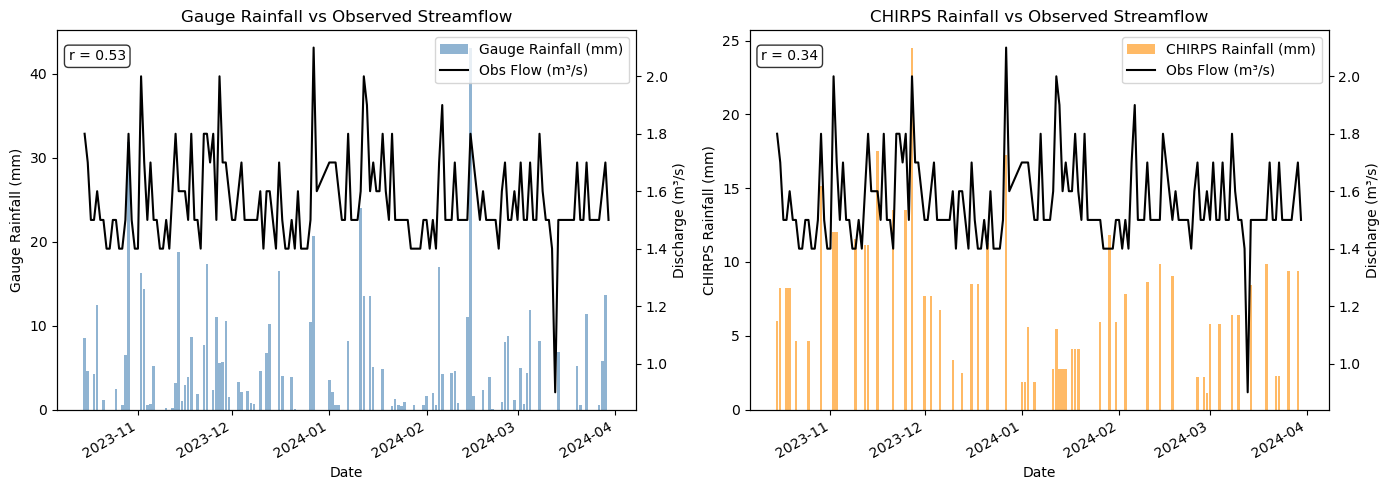

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets = [
    ('Gauge', 'Gauge Rainfall (mm)', 'steelblue'),
    ('CHIRPS', 'CHIRPS Rainfall (mm)', 'darkorange'),
]

for ax, (rain_col, rain_label, rain_color) in zip(axes, datasets):
    ax2 = ax.twinx()

    # Rainfall bars on left y-axis
    ax.bar(merged_df_discharge.index, merged_df_discharge[rain_col], color=rain_color, alpha=0.6,
           label=rain_label, width=0.8)

    # Observed flow line on right y-axis
    ax2.plot(merged_df_discharge.index, merged_df_discharge['Obs Flow (M3/S)'], color='black',
             linewidth=1.5, label='Obs Flow (m³/s)')

    # Pearson correlation
    r = merged_df_discharge[rain_col].corr(merged_df_discharge['Obs Flow (M3/S)'])
    ax.text(0.02, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_xlabel('Date')
    ax.set_ylabel(rain_label)
    ax2.set_ylabel('Discharge (m³/s)')
    ax.set_title(f'{rain_col} Rainfall vs Observed Streamflow')

    # Combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='upper right')

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()